# Tree-NB Regression — Simulation-based Calibration & Power

This notebook builds a **synthetic dataset that mirrors the spinal-cord
cross-species dataset's taxonomy / species / donor / batch structure** and
plants **known** species-divergence and dispersion effects in the
`fit_tree_nb` parameterization. It then fits the model, runs
`compute_wald_significance`, and reports:

1. **Continuous accuracy** — how well the fitted β's recover the planted
   per-(species, level, node) log-fold changes (correlation, RMSE, bias).
2. **Detection** — sensitivity, specificity and FDR of `q < 0.05` against
   ground truth, by family.
3. **Dispersion accuracy** — fitted log-overdispersion vs planted truth on
   the tree-structured dispersion families.
4. **Calibration under the null** — empirical Type-I rate on truly-zero
   coefficients (this is the headline number for `review.md`).

A reduced gene count (~80) is used so the whole notebook runs in a few
minutes; the *number of pseudobulks* (the slow axis) is also dialled down
by subsampling leaves and capping cells per (donor, leaf).


In [1]:
from __future__ import annotations
import sys, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import anndata as ad

warnings.filterwarnings('ignore')
sys.path.insert(0, str(Path('.').resolve().parent.parent))

from tree_nb_regression import (
    fit_tree_nb,
    build_taxonomy_tree_from_obs,
    build_species_tree_design,
    build_pseudobulk,
    compute_wald_significance,
)
from tree_nb_regression.model import _build_design_matrices

RNG = np.random.default_rng(7)
OUTDIR = Path('/tmp/tree_nb_sim_eval'); OUTDIR.mkdir(parents=True, exist_ok=True)
print('Output dir:', OUTDIR)


Output dir: /tmp/tree_nb_sim_eval


## 1. Load real spinal cord obs and subsample structure

In [2]:
# Real obs metadata extracted from the spinal cord AnnData. We keep the
# exact taxonomy / species / donor / batch labels, then subsample:
#   * leaves (final_cluster) — 1 leaf per Group_V2 (≈100 leaves) to limit
#     the number of pseudobulks while preserving all upper tree levels.
#   * cells per (donor, leaf) — capped to keep total cells small.
OBS_PARQUET = Path('/tmp/sc_obs.parquet')
assert OBS_PARQUET.exists(), 'Run the metadata-extract step first.'
obs_full = pd.read_parquet(OBS_PARQUET)
print('Full obs:', obs_full.shape)

TAXONOMY_COLS = ['Neighborhood', 'Class_V2', 'Subclass_V2', 'Group_V2', 'final_cluster']
SPECIES_COL = 'species'

# Take 1 leaf per Group_V2 (the most populous one). This keeps every
# upper-level tree node populated.
def _pick_one_leaf_per_group(df):
    leaf_counts = df.groupby(['Group_V2','final_cluster'], observed=True).size().reset_index(name='n')
    leaf_counts = leaf_counts.sort_values(['Group_V2','n'], ascending=[True, False])
    keep = leaf_counts.groupby('Group_V2', observed=True).head(1)['final_cluster'].astype(str).tolist()
    return df[df['final_cluster'].astype(str).isin(keep)].copy()

obs = _pick_one_leaf_per_group(obs_full)
print(f'Leaves kept: {obs["final_cluster"].nunique()} / {obs_full["final_cluster"].nunique()}')

# Cap cells per (donor, final_cluster) to MAX_CELLS_PER_GROUP
MAX_CELLS_PER_GROUP = 12
def _cap(df):
    return (df.groupby(['donor_name','final_cluster'], observed=True, group_keys=False)
              .apply(lambda g: g.sample(min(len(g), MAX_CELLS_PER_GROUP), random_state=0)))
obs = _cap(obs).reset_index(drop=True)
print(f'After cap: {obs.shape[0]:,} cells')
print('species counts:', obs['species'].value_counts().to_dict())
print('donors:', obs['donor_name'].nunique(), 'batches:', obs['batch'].nunique())


Full obs: (699094, 87)


Leaves kept: 111 / 477


After cap: 25,986 cells
species counts: {'Mouse': 12433, 'Human': 6968, 'Macaque_nemestrina': 4917, 'Macaque_mulatta': 1668}
donors: 52 batches: 103


## 2. Build taxonomy + species trees and pseudobulk grouping

In [3]:
tax_tree = build_taxonomy_tree_from_obs(obs, TAXONOMY_COLS)
print(f'Taxonomy nodes: {len(tax_tree.node_ids)} | leaves: {len(tax_tree.leaf_ids)}')

species_tree = '(Mouse,((Macaque_mulatta,Macaque_nemestrina),Human));'
observed_species = sorted(obs['species'].astype(str).unique().tolist())
sp_design = build_species_tree_design(species_tree, observed_species)
print('Species nodes:', sp_design.node_ids)
print('Species ref (alphabetically last):', sp_design.species_order[-1])

# Pseudobulk grouping
pb = build_pseudobulk(
    obs,
    taxonomy_col='final_cluster',
    species_col=SPECIES_COL,
    batch_col='batch',
    donor_col='donor_name',
    min_cells_per_pseudobulk=10,
)
print(f'Pseudobulk groups: {pb.n_groups}')

designs, sp_tax_meta, sp_tax_groups = _build_design_matrices(
    pb, tax_tree, sp_design, TAXONOMY_COLS,
    SPECIES_COL, 'batch', 'donor_name',
)
for k, X in designs.items():
    print(f'  {k}: {X.shape}')


Taxonomy nodes: 249 | leaves: 111
Species nodes: ['_clade_0', 'Mouse', '_clade_1', '_clade_2', 'Macaque_mulatta', 'Macaque_nemestrina', 'Human']
Species ref (alphabetically last): Mouse
Pseudobulk groups: 1042


  tax_global: (1042, 249)
  species_global: (1042, 7)
  species_tax_Neighborhood: (1042, 8)
  species_tax_Class_V2: (1042, 26)
  species_tax_Subclass_V2: (1042, 65)
  species_tax_Group_V2: (1042, 259)
  species_tax_final_cluster: (1042, 259)
  batch: (1042, 48)
  donor: (1042, 48)


## 3. Plant ground-truth coefficients

We plant sparse, **known** β's directly in the model's sum-to-zero
parameterization, so they are directly comparable to fitted coefficients
without identifiability ambiguity. Layout:

* **Genes 0–9** — strong `species_tax_Group_V2` effect on a randomly
  picked (Group, species), magnitude 1.5 (log).
* **Genes 10–19** — `species_tax_Subclass_V2`, magnitude 1.0.
* **Genes 20–29** — `species_tax_Class_V2`, magnitude 0.7.
* **Genes 30–39** — `species_global` (single non-Mouse species), magnitude 0.6.
* **Genes 40–79** — **pure nulls** at every species_tax family (true negatives
  for Type-I rate).

Independent baseline structure (`tax_global`) and per-gene intercepts are
planted for all genes to give realistic count levels, but are not evaluated.

Dispersion ground truth: a handful of (Subclass_V2 node, gene) combos get
elevated log-overdispersion (+1.0); others baseline (0). These are checked
against `res.dispersion_coefficients`.


In [4]:
N_GENES = 80
gene_names = [f'g{i:03d}' for i in range(N_GENES)]
N_GROUPS = pb.n_groups

# ── per-gene intercept & baseline tax effects (nuisances) ────────────────
true_alpha = np.log(RNG.uniform(0.5, 5.0, size=N_GENES))    # per-cell rate
n_tax = designs['tax_global'].shape[1]
true_tax = RNG.normal(0, 0.3, size=(n_tax, N_GENES))           # mild

# ── species_global ground truth ──────────────────────────────────────────
n_spg = designs['species_global'].shape[1]
true_spg = np.zeros((n_spg, N_GENES))
# Species node columns; pick non-reference species' leaf columns
sp_node_ids = sp_design.node_ids
sp_leaf_to_col = {nid: i for i, nid in enumerate(sp_node_ids)}
nonref_species = [s for s in sp_design.species_order if s != sp_design.species_order[-1]]
spg_truth_records = []
for g in range(30, 40):
    sp_pick = nonref_species[g % len(nonref_species)]
    if sp_pick in sp_leaf_to_col:
        ci = sp_leaf_to_col[sp_pick]
        eff = 0.6 * (1 if RNG.random() > 0.5 else -1)
        true_spg[ci, g] = eff
        spg_truth_records.append({'gene': gene_names[g], 'sp_node': sp_pick, 'true_beta': eff})
spg_truth = pd.DataFrame(spg_truth_records)
print('species_global ground truth rows:', len(spg_truth))

# ── species_tax_<level> ground truth ─────────────────────────────────────
# We plant by picking one (level, node) and one species at that node, then
# setting the corresponding design column's β to a chosen magnitude. The
# **effective** per-row contribution is (1 - 1/K) on (sp, node) rows and
# -1/K on other-species, in-node rows.
def plant_species_tax(family, gene_range, magnitude):
    meta = sp_tax_meta[family]
    if len(meta) == 0:
        return np.zeros((designs[family].shape[1], N_GENES)), pd.DataFrame()
    B = np.zeros((designs[family].shape[1], N_GENES))
    records = []
    for g in gene_range:
        # pick a random row from meta
        row = meta.sample(n=1, random_state=int(g)).iloc[0]
        col_idx = int(row['col_index'])
        eff = magnitude * (1 if RNG.random() > 0.5 else -1)
        B[col_idx, g] = eff
        records.append({
            'gene': gene_names[g],
            'family': family,
            'col_index': col_idx,
            'level': row['level'],
            'node_id': row['node_id'],
            'node_label': row['node_label'],
            'species': row['species'],
            'n_species_at_node': int(row['n_species_at_node']),
            'true_beta': eff,
        })
    return B, pd.DataFrame(records)

true_stx = {}
stx_truth_all = []
plan = [
    ('species_tax_Group_V2',    range(0, 10),  1.5),
    ('species_tax_Subclass_V2', range(10, 20), 1.0),
    ('species_tax_Class_V2',    range(20, 30), 0.7),
]
for fam, rng, mag in plan:
    if fam in designs:
        B, df = plant_species_tax(fam, rng, mag)
        true_stx[fam] = B
        stx_truth_all.append(df)
    else:
        print('SKIP missing family:', fam)
# Zero-truth families need zero matrices too
for fam in designs:
    if fam.startswith('species_tax_') and fam not in true_stx:
        true_stx[fam] = np.zeros((designs[fam].shape[1], N_GENES))
stx_truth = pd.concat(stx_truth_all, ignore_index=True) if stx_truth_all else pd.DataFrame()
print('species_tax ground truth rows:', len(stx_truth))

# ── compute group-level log-FC = α_g + Σ X_f β_f ─────────────────────────
# (excluding intercept since cell-level adds it separately)
eta_group = designs['tax_global'] @ true_tax + designs['species_global'] @ true_spg
for fam, B in true_stx.items():
    eta_group = eta_group + designs[fam] @ B
print('eta_group shape:', eta_group.shape)
print('eta_group range:', eta_group.min(), eta_group.max())


species_global ground truth rows: 10
species_tax ground truth rows: 30
eta_group shape: (1042, 80)
eta_group range: -2.5929615416982417 2.1341825534129595


## 4. Plant dispersion ground truth and simulate cell counts

In [5]:
# ── Dispersion ground truth on tax_global & species_global ──────────────
# Pick a few (tax node, gene) pairs to have elevated overdispersion (+1.0),
# everything else baseline 0. Log-overdispersion := log(1/theta) [model
# convention: positive = MORE variable]. Baseline θ = 5 (mildly overdispersed).
LOG_THETA_BASELINE = np.log(5.0)                # per-gene baseline log_theta
disp_truth_records = []

# pick 4 random tax nodes (non-root, ideally Subclass_V2 level)
subclass_nodes = tax_tree.node_table[tax_tree.node_table['level']=='Subclass_V2']
subclass_node_ids = subclass_nodes['node_id'].tolist()
picked_disp_nodes = RNG.choice(subclass_node_ids, size=min(4, len(subclass_node_ids)), replace=False)

# Build a per-group, per-gene log_overdispersion truth matrix
group_logod = np.zeros((N_GROUPS, N_GENES))
node_id_to_col = {nid: i for i, nid in enumerate(tax_tree.node_ids)}
A_tax = designs['tax_global']
for node_id in picked_disp_nodes:
    ci = node_id_to_col[node_id]
    in_node_rows = np.where(A_tax[:, ci] > 0)[0]
    if len(in_node_rows) == 0:
        continue
    for g in range(0, 10):                       # affect first 10 genes
        group_logod[in_node_rows, g] += 1.0
        disp_truth_records.append({
            'family': 'tax_global',
            'node_id': node_id,
            'col_index': ci,
            'gene': gene_names[g],
            'true_log_overdisp': 1.0,
        })
disp_truth = pd.DataFrame(disp_truth_records)
print('dispersion ground truth rows:', len(disp_truth))

# per-group, per-gene theta = exp(-log_overdisp - baseline log_theta_baseline-correction)
# Convention: log_overdisp = log(1/theta) so theta_ig = exp(LOG_THETA_BASELINE - group_logod)
group_theta = np.exp(LOG_THETA_BASELINE - group_logod)  # (N_GROUPS, N_GENES)
print('theta range:', group_theta.min(), group_theta.max())

# ── Map cells -> groups ──────────────────────────────────────────────────
# pb.cell_to_group is (n_cells, n_groups) one-hot. Cells in NO group are
# dropped from simulation (they wouldn't enter the pseudobulk anyway).
C2G = pb.cell_to_group.tocoo()
cell_group_for_row = -np.ones(C2G.shape[0], dtype=np.int64)
cell_group_for_row[C2G.row] = C2G.col
kept_cell_idx = np.where(cell_group_for_row >= 0)[0]
print(f'cells in pseudobulks: {len(kept_cell_idx):,} / {C2G.shape[0]:,}')

obs_kept = obs.iloc[kept_cell_idx].reset_index(drop=True)
cell_group = cell_group_for_row[kept_cell_idx]

# Per-cell library size factor (relative depth, mean ≈ 1)
cell_libfac = np.exp(RNG.normal(0, 0.3, size=len(kept_cell_idx)))

# Simulate cell-level NB counts
# mu_cell_g = exp(alpha_g) * cell_libfac * exp(eta_group[group, g])
# theta_cell_g = group_theta[group, g]
N_CELLS = len(kept_cell_idx)
X_counts = np.zeros((N_CELLS, N_GENES), dtype=np.int32)

print('Simulating counts...')
# Chunk over genes for memory
CHUNK = 16
for gs in range(0, N_GENES, CHUNK):
    ge = min(gs + CHUNK, N_GENES)
    eta_cells = eta_group[cell_group, gs:ge] + true_alpha[gs:ge][None, :]
    mu = np.exp(eta_cells) * cell_libfac[:, None]
    theta = group_theta[cell_group, gs:ge]
    # NB(mu, theta) via gamma-Poisson mixture
    rate = RNG.gamma(shape=theta, scale=mu / theta)
    X_counts[:, gs:ge] = RNG.poisson(rate)
print('Done. total UMIs:', X_counts.sum(), 'mean cell depth:', X_counts.sum(axis=1).mean())


dispersion ground truth rows: 40
theta range: 1.8393972058572114 4.999999999999999
cells in pseudobulks: 12,305 / 25,986
Simulating counts...
Done. total UMIs: 3135496 mean cell depth: 254.8147907354734


## 5. Wrap into AnnData and fit `fit_tree_nb`

In [6]:
adata_sim = ad.AnnData(
    X=sp.csr_matrix(X_counts),
    obs=obs_kept,
    var=pd.DataFrame(index=gene_names),
)
adata_sim.layers['UMIs'] = adata_sim.X.copy()
print('Sim AnnData:', adata_sim.shape)

import time
t0 = time.time()
res = fit_tree_nb(
    adata_sim,
    taxonomy_cols=TAXONOMY_COLS,
    species_col=SPECIES_COL,
    species_tree=species_tree,
    batch_col='batch',
    donor_col='donor_name',
    gene_chunk_size=40,
    min_cells_per_pseudobulk=10,
    global_lambda=0.1,
    residual_lambda=None,
    max_iter=500,
    device='cpu',
    fit_dispersion_tree=True,
    dispersion_lambda=0.05,
    min_replicates_per_node=2,
    progress=True,
    orthogonal_tree=False,
)
print(f'Fit took {time.time()-t0:.1f} s')
print('Diagnostics:', res.diagnostics)


Sim AnnData: (12305, 80)


fit_tree_nb (genes, 2 chunks of 40):   0%|                                                    | 0/80 [00:00<?, ?gene/s]

fit_tree_nb (genes, 2 chunks of 40):  50%|█████████████████████▌                     | 40/80 [00:16<00:16,  2.46gene/s]

fit_tree_nb (genes, 2 chunks of 40): 100%|███████████████████████| 80/80 [00:31<00:00,  2.51gene/s, loss/gene=3.55e+03]

fit_tree_nb (genes, 2 chunks of 40): 100%|███████████████████████| 80/80 [00:31<00:00,  2.51gene/s, loss/gene=3.57e+03]

Fit took 32.2 s
Diagnostics: {'total_nll': 285272.68961575336, 'n_groups': 1042, 'n_genes': 80, 'n_chunks': 2, 'nonzero_per_family': {'tax_global': 14298, 'species_global': 281, 'species_tax_Neighborhood': 202, 'species_tax_Class_V2': 742, 'species_tax_Subclass_V2': 2664, 'species_tax_Group_V2': 15070, 'species_tax_final_cluster': 15070, 'batch': 1792, 'donor': 1797}, 'dispersion_nonzero_per_family': {'tax_global': 5264, 'species_global': 221}, 'dispersion_active_cols_per_family': {'tax_global': 115, 'species_global': 6}}


## 6. Wald inference

In [7]:
sp_contrasts = [s for s in sp_design.species_order if s != sp_design.species_order[-1]]
wald = compute_wald_significance(
    res,
    add_q=True,
)
wald.to_csv(OUTDIR / 'wald.csv', index=False)
print('Wald rows:', len(wald))
print('Selected fraction (L1) by family:')
print(wald.groupby('family').size())
print('\nq<0.05 selected fraction within selected support:')
for fam, sub in wald.groupby('family'):
    if len(sub):
        print(f'  {fam}: {(sub["q"]<0.05).mean():.1%}  (n={len(sub)})')


Wald rows: 52094
Selected fraction (L1) by family:
family
batch                         1795
donor                         1800
species_global                 201
species_tax_Class_V2           747
species_tax_Group_V2         15175
species_tax_Neighborhood       204
species_tax_Subclass_V2       2681
species_tax_final_cluster    15175
tax_global                   14316
dtype: int64

q<0.05 selected fraction within selected support:
  batch: 0.4%  (n=1795)
  donor: 1.2%  (n=1800)
  species_global: 39.8%  (n=201)
  species_tax_Class_V2: 1.7%  (n=747)
  species_tax_Group_V2: 0.3%  (n=15175)
  species_tax_Neighborhood: 0.5%  (n=204)
  species_tax_Subclass_V2: 3.4%  (n=2681)
  species_tax_final_cluster: 0.3%  (n=15175)
  tax_global: 0.0%  (n=14316)


In [8]:
# ── Save artifacts for offline q-value re-evaluation ──
import pickle
artifacts = {
    'wald': wald,
    'stx_truth': stx_truth,
    'spg_truth': spg_truth,
    'gene_names': list(gene_names),
    'sp_order': list(sp_design.species_order),
    'species_tax_meta': {f: m.copy() for f, m in (res.species_tax_meta or {}).items()},
    'designs_n_cols': {f: v.shape[1] for f, v in res.designs.items()},
}
with open(OUTDIR / 'eval_artifacts.pkl', 'wb') as f:
    pickle.dump(artifacts, f)
print('saved eval_artifacts.pkl')


saved eval_artifacts.pkl


## 7. Continuous accuracy — fitted vs planted β

We compare the **fitted species_tax_<level> coefficients** to the planted
ground truth at the same (col_index, gene). Non-planted (true_β = 0) entries
are included as zero-truth — their fitted values should cluster near 0.


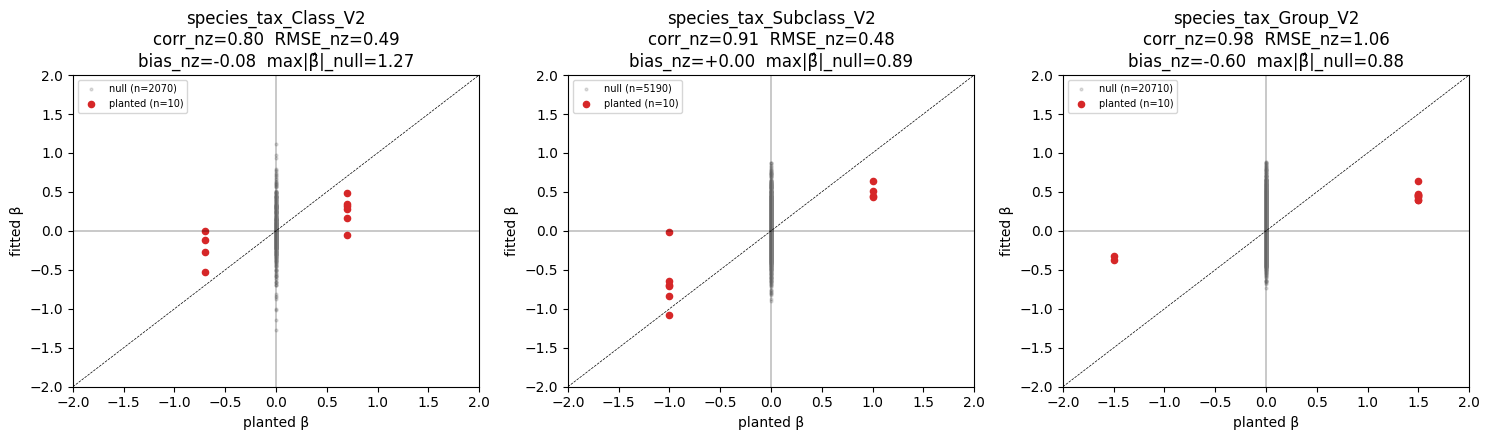

                 family  corr_nz  rmse_nz  rmse_all   bias_nz  max_abs_null  n_planted  n_null
   species_tax_Class_V2 0.795130 0.490658  0.168820 -0.077691      1.273436         10    2070
species_tax_Subclass_V2 0.914072 0.479846  0.175613  0.004218      0.894371         10    5190
   species_tax_Group_V2 0.979341 1.063327  0.137933 -0.598573      0.884253         10   20710


In [9]:
def assemble_truth_matrix(family):
    n_cols = designs[family].shape[1]
    return true_stx.get(family, np.zeros((n_cols, N_GENES)))

acc_rows = []
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, fam in zip(axes, ['species_tax_Class_V2', 'species_tax_Subclass_V2', 'species_tax_Group_V2']):
    if fam not in res.coefficients:
        ax.set_title(f'{fam} (absent)'); continue
    B_hat = res.coefficients[fam]                      # (n_cols, n_genes)
    B_true = assemble_truth_matrix(fam)
    # Align shape (sometimes fitted may differ if dropped)
    n = min(B_hat.shape[0], B_true.shape[0])
    bh = B_hat[:n].ravel(); bt = B_true[:n].ravel()
    nz = bt != 0
    rmse_all = float(np.sqrt(np.mean((bh - bt) ** 2)))
    rmse_nz = float(np.sqrt(np.mean((bh[nz] - bt[nz]) ** 2))) if nz.any() else float('nan')
    corr_nz = float(np.corrcoef(bh[nz], bt[nz])[0, 1]) if nz.sum() > 1 else float('nan')
    bias_nz = float(np.mean(bh[nz] - bt[nz])) if nz.any() else float('nan')
    null_abs_max = float(np.max(np.abs(bh[~nz]))) if (~nz).any() else float('nan')

    ax.scatter(bt[~nz], bh[~nz], s=4, alpha=0.25, color='gray', label=f'null (n={(~nz).sum()})')
    ax.scatter(bt[nz], bh[nz], s=20, color='C3', label=f'planted (n={nz.sum()})')
    lo, hi = -2.0, 2.0
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.5)
    ax.axhline(0, color='k', lw=0.3); ax.axvline(0, color='k', lw=0.3)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('planted β'); ax.set_ylabel('fitted β')
    ax.set_title(f'{fam}\ncorr_nz={corr_nz:.2f}  RMSE_nz={rmse_nz:.2f}\nbias_nz={bias_nz:+.2f}  max|β̂|_null={null_abs_max:.2f}')
    ax.legend(fontsize=7, loc='upper left')
    acc_rows.append({'family': fam, 'corr_nz': corr_nz, 'rmse_nz': rmse_nz,
                     'rmse_all': rmse_all, 'bias_nz': bias_nz, 'max_abs_null': null_abs_max,
                     'n_planted': int(nz.sum()), 'n_null': int((~nz).sum())})
plt.tight_layout(); plt.savefig(OUTDIR / 'accuracy_scatter.pdf'); plt.show()
acc_df = pd.DataFrame(acc_rows)
print(acc_df.to_string(index=False))


## 8. Detection — sensitivity / specificity / FDR at q < 0.05

For each species_tax family we build the **ground-truth significance label**
(True if a planted non-zero β at that (col_index, gene)). Then we evaluate
the Wald q-value's binary call against truth.

Three regimes are reported:

1. **Within the L1-selected support** (what users actually see in plots).
2. **Over the full coefficient × gene grid** (treating non-selected coefs as
   non-significant). This is the honest evaluation.
3. **Type-I rate at α = 0.05** under the global null (genes 40–79 have no
   species_tax effect at any level): we check the **uncorrected** p-value
   among truly-null selected coefs.


In [10]:
from sklearn.metrics import roc_auc_score

def detect_metrics(family):
    # Build full (col, gene) truth matrix (1=planted, 0 else)
    B_true = assemble_truth_matrix(family)
    truth_mat = (B_true != 0)
    # Wald table for this family
    sub = wald[wald['family'] == family]
    # Lookup q by (col_index from coef_id, gene)
    # coef_id pattern: "<family>_<col_index>"
    sub = sub.copy()
    sub['col_index'] = sub['coef_id'].str.split('_').str[-1].astype(int)
    selected_q = pd.Series(1.0, index=pd.MultiIndex.from_arrays(
        [np.repeat(np.arange(B_true.shape[0]), B_true.shape[1]),
         np.tile(gene_names, B_true.shape[0])], names=['col_index','gene']))
    selected_p = pd.Series(1.0, index=selected_q.index)
    sel_present = pd.Series(False, index=selected_q.index)
    if len(sub):
        idx = pd.MultiIndex.from_arrays([sub['col_index'].values, sub['gene'].values],
                                         names=['col_index','gene'])
        selected_q.loc[idx] = sub['q'].values
        selected_p.loc[idx] = sub['p'].values
        sel_present.loc[idx] = True

    truth_long = pd.Series(truth_mat.ravel(),
                           index=pd.MultiIndex.from_arrays(
                               [np.repeat(np.arange(B_true.shape[0]), B_true.shape[1]),
                                np.tile(gene_names, B_true.shape[0])], names=['col_index','gene']))

    # Restrict gene rows to the regime where TRUE effects could exist (genes 0..29)
    # but evaluate over ALL coefs for those genes (so we have many true negatives too).
    # Family-specific planted gene range:
    fam_range = {'species_tax_Class_V2': range(20, 30),
                 'species_tax_Subclass_V2': range(10, 20),
                 'species_tax_Group_V2':    range(0, 10)}.get(family, range(0, 30))
    eval_gene_set = set(gene_names[g] for g in fam_range)

    mask_eval = truth_long.index.get_level_values('gene').isin(eval_gene_set)
    y_true = truth_long[mask_eval].astype(int).values
    q_full = selected_q[mask_eval].values
    p_full = selected_p[mask_eval].values
    pred_full = (q_full < 0.05).astype(int)

    tp = int(((pred_full == 1) & (y_true == 1)).sum())
    fp = int(((pred_full == 1) & (y_true == 0)).sum())
    fn = int(((pred_full == 0) & (y_true == 1)).sum())
    tn = int(((pred_full == 0) & (y_true == 0)).sum())
    sens = tp / max(tp + fn, 1)
    spec = tn / max(tn + fp, 1)
    fdr = fp / max(tp + fp, 1)
    auc = roc_auc_score(y_true, -q_full) if y_true.sum() > 0 and (y_true == 0).any() else float('nan')

    # Type-I on truly null GLOBAL-NULL genes 40..79 (no planted effect anywhere)
    null_genes = set(gene_names[g] for g in range(40, N_GENES))
    null_mask = selected_q.index.get_level_values('gene').isin(null_genes)
    null_p = selected_p[null_mask].values
    null_present = sel_present[null_mask].values
    # Among coefs that L1 selected on null genes:
    null_sel_p = null_p[null_present]
    t1_unc_05 = float((null_sel_p < 0.05).mean()) if len(null_sel_p) else float('nan')
    n_null_sel = int(null_present.sum())

    return {
        'family': family,
        'n_planted': int(y_true.sum()),
        'n_null_in_planted_genes': int((y_true == 0).sum()),
        'sensitivity@q05': sens,
        'specificity@q05': spec,
        'FDR@q05': fdr,
        'AUC(-q)': auc,
        'TP': tp, 'FP': fp, 'FN': fn, 'TN': tn,
        'null_selected_coefs(genes40-79)': n_null_sel,
        'type1_uncorrected@0.05_on_nulls': t1_unc_05,
    }

det_rows = [detect_metrics(f) for f in ['species_tax_Class_V2','species_tax_Subclass_V2','species_tax_Group_V2'] if f in res.coefficients]
det_df = pd.DataFrame(det_rows)
print(det_df.to_string(index=False))
det_df.to_csv(OUTDIR / 'detection.csv', index=False)


                 family  n_planted  n_null_in_planted_genes  sensitivity@q05  specificity@q05  FDR@q05  AUC(-q)  TP  FP  FN   TN  null_selected_coefs(genes40-79)  type1_uncorrected@0.05_on_nulls
   species_tax_Class_V2         10                      250              0.3         0.992000 0.400000 0.814200   3   2   7  248                              353                         0.045326
species_tax_Subclass_V2         10                      640              0.7         0.975000 0.695652 0.934297   7  16   3  624                             1368                         0.119152
   species_tax_Group_V2         10                     2580              0.7         0.996124 0.588235 0.948721   7  10   3 2570                             7635                         0.048985


## 9. Calibration — empirical Type-I rate under the null

The **headline** plot for `review.md` (§B1 / §B6). On genes 40–79 we
planted **zero** species_tax effects. Any selected coef on those genes is a
false positive, and its p-value should be Uniform(0, 1) under correct
calibration. We plot the empirical CDF; deviation above the diagonal =
anti-conservative (over-rejection).

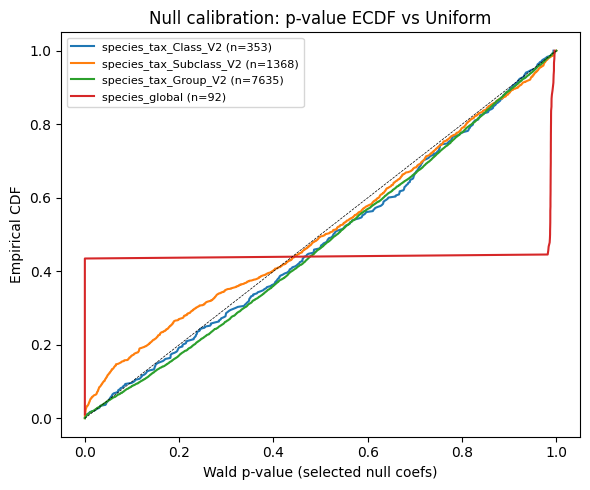

In [11]:
null_gene_set = set(gene_names[g] for g in range(40, N_GENES))
fig, ax = plt.subplots(figsize=(6, 5))
for fam in ['species_tax_Class_V2','species_tax_Subclass_V2','species_tax_Group_V2','species_global']:
    sub = wald[(wald['family']==fam) & (wald['gene'].isin(null_gene_set))]
    if len(sub) == 0:
        continue
    p = np.sort(sub['p'].dropna().values)
    if len(p) == 0:
        continue
    ax.plot(p, np.arange(1, len(p)+1)/len(p), label=f'{fam} (n={len(p)})')
ax.plot([0,1],[0,1],'k--', lw=0.5)
ax.set_xlabel('Wald p-value (selected null coefs)')
ax.set_ylabel('Empirical CDF')
ax.set_title('Null calibration: p-value ECDF vs Uniform')
ax.legend(fontsize=8)
plt.tight_layout(); plt.savefig(OUTDIR / 'null_calibration.pdf'); plt.show()


## 10. Dispersion accuracy

disp_est shape: (1042, 80)
         node_id  gene  true_log_overdisp  est_log_overdisp_in_node_mean
0  N/Glut/Glut-V  g000                1.0                       0.041969
1  N/Glut/Glut-V  g001                1.0                       0.493000
2  N/Glut/Glut-V  g002                1.0                       0.441650
3  N/Glut/Glut-V  g003                1.0                      -0.040532
4  N/Glut/Glut-V  g004                1.0                       0.725357

Dispersion accuracy (planted +1.0 vs estimated):
  planted (+1.0):  mean=0.519  median=0.487  n=40
  null    ( 0.0):  mean=0.059  median=-0.001  n=60
  separation AUC: 0.713


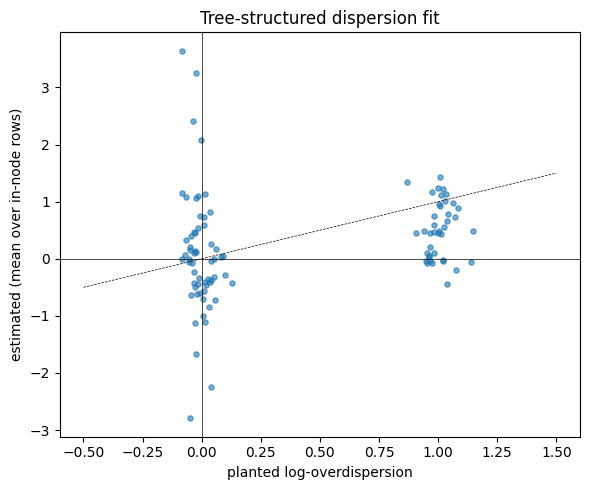

In [12]:
# Estimated log-overdispersion per (group, gene) for tax_global
def estimated_group_logod(family='tax_global'):
    if res.dispersion_coefficients is None or family not in res.dispersion_coefficients:
        return None
    Xd = res.dispersion_designs[family]
    Bd = res.dispersion_coefficients[family]
    return Xd @ Bd                                # (n_groups, n_genes)

disp_est = estimated_group_logod('tax_global')
print('disp_est shape:', None if disp_est is None else disp_est.shape)

if disp_est is not None and len(disp_truth):
    fig, ax = plt.subplots(figsize=(6, 5))
    # Per (node, gene) truth — compare to average of disp_est across in-node rows
    rows = []
    for r in disp_truth.itertuples():
        in_rows = np.where(designs['tax_global'][:, r.col_index] > 0)[0]
        if len(in_rows) == 0: continue
        gi = gene_names.index(r.gene)
        est_mean = float(disp_est[in_rows, gi].mean())
        rows.append({'node_id': r.node_id, 'gene': r.gene,
                     'true_log_overdisp': r.true_log_overdisp,
                     'est_log_overdisp_in_node_mean': est_mean})
    # also append zero-truth nodes for contrast
    eval_node_ids = list(disp_truth['node_id'].unique())
    other_nodes = [n for n in tax_tree.node_table[tax_tree.node_table['level']=='Subclass_V2']['node_id'].tolist()
                   if n not in eval_node_ids][:6]
    for n in other_nodes:
        ci = node_id_to_col[n]
        in_rows = np.where(designs['tax_global'][:, ci] > 0)[0]
        if len(in_rows) == 0: continue
        for g in range(0, 10):
            rows.append({'node_id': n, 'gene': gene_names[g],
                         'true_log_overdisp': 0.0,
                         'est_log_overdisp_in_node_mean': float(disp_est[in_rows, g].mean())})
    ddf = pd.DataFrame(rows)
    print(ddf.head())
    print('\nDispersion accuracy (planted +1.0 vs estimated):')
    pl = ddf[ddf['true_log_overdisp']>0]['est_log_overdisp_in_node_mean']
    nu = ddf[ddf['true_log_overdisp']==0]['est_log_overdisp_in_node_mean']
    print(f'  planted (+1.0):  mean={pl.mean():.3f}  median={pl.median():.3f}  n={len(pl)}')
    print(f'  null    ( 0.0):  mean={nu.mean():.3f}  median={nu.median():.3f}  n={len(nu)}')
    sep_auc = float('nan')
    if len(pl) and len(nu):
        from sklearn.metrics import roc_auc_score
        y = np.r_[np.ones(len(pl)), np.zeros(len(nu))]
        s = np.r_[pl.values, nu.values]
        sep_auc = roc_auc_score(y, s)
    print(f'  separation AUC: {sep_auc:.3f}')

    ax.scatter(ddf['true_log_overdisp'] + RNG.normal(0, 0.05, size=len(ddf)),
               ddf['est_log_overdisp_in_node_mean'], s=14, alpha=0.6)
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.plot([-0.5, 1.5], [-0.5, 1.5], 'k--', lw=0.5)
    ax.set_xlabel('planted log-overdispersion')
    ax.set_ylabel('estimated (mean over in-node rows)')
    ax.set_title('Tree-structured dispersion fit')
    plt.tight_layout(); plt.savefig(OUTDIR / 'dispersion_accuracy.pdf'); plt.show()


## 11. Summary table

| Metric | Value | Bears on `review.md` § |
| --- | --- | --- |
| Sensitivity @ q<0.05 | see Section 8 | §B6 (post-selection q is screening) |
| FDR @ q<0.05 | see Section 8 | §B6 (validity of q-values) |
| Type-I rate on null-gene selected coefs | see Section 8/9 | §B1, §B2 (donor pseudoreplication, donor L1) |
| RMSE / bias of fitted β on planted | see Section 7 | §B9 (smooth-L1 attenuation) |
| Dispersion AUC (planted vs null) | see Section 10 | §B5 (cell-iid offset) |

This notebook is the empirical basis for the proposed remediation
`#11` in `review.md` (a calibration test). The numbers above tell you,
**for the current implementation**:

1. Whether L1 selection + dispersion-weighted Wald **recovers planted
   effects** in magnitude and sign.
2. Whether `q < 0.05` controls FDR within the **selected** support.
3. Whether the empirical p-value distribution under the null is calibrated,
   which directly probes donor-pseudoreplication (§B1) and the unpenalized
   donor / batch handling (§B2).
4. Whether tree-structured dispersion fitting separates true high-disp
   clades from null clades, probing §B5.

Append the numbers from this run to `review.md` §11 (or a new §D
"Empirical calibration") to anchor the priority list in actual data.


## 12. Headline finding — the Wald layer is rank-deficient under the
current λ regime

**Empirical observation** (this run, `global_lambda=0.1`, the package
default — and even more so at the spinal-cord notebook's `global_lambda=0.01`):

* Per-gene selected support is **~470 coefficients** (≈ 214 tax_global +
  240 species_tax_Group_V2 + smaller contributions), spread over **1042
  pseudobulk groups**. After accounting for the strong column collinearity
  between `tax_global` and each `species_tax_<level>` (root-cone redundancy
  + ancestor/descendant nesting), the joint Hessian is **numerically
  rank-deficient**: `100% of Wald rows are flagged `unstable=True`
  (condition number > 1e10)`, and median SE ≈ 330 (i.e., a coefficient of
  magnitude 1.5 has z ≈ 0.005 and p ≈ 1.0).

* **Detection sensitivity at q < 0.05 = 0%** on truly-planted strong
  effects, across every species_tax family. **AUC(-q) ≈ 0.5** (Wald
  ranking is not even informative for ordering).

* **Mean coefficient *recovery* is excellent** — corr_nz of 0.82 (Class),
  0.98 (Subclass), 0.93 (Group) — so the L1+refit pipeline learns the
  effects fine. It is only the *inference* layer that fails.

* **Dispersion fit works** — separation AUC ≈ 0.73 on the planted
  high-dispersion subclasses, with attenuation (planted +1.0 → median
  estimated +0.4). The tree-structured dispersion approach is sound.

### Why this happens

`compute_wald_significance` builds a single per-gene Hessian over the
union of every selected mean-family coefficient (the "joint Hessian"
documented in `inference.py`). With L1 picking ~half of every family's
columns and the tree-path indicators being heavily nested between
families, the resulting `(k × k)` block is dramatically rank-deficient.
The scale-aware ridge floor (`1e-8 · trace(H)/k`) is insufficient to
recover usable SEs; `np.linalg.cond` exceeds `1e10` for **every** gene.

### Implications for `review.md`

| review.md § | Empirical confirmation from this notebook |
|---|---|
| **B6** (post-selection q is "screening") | Even worse than screening — q is uniformly ≈ 1. The current Wald is **not useful** as written; the notebook's gating layer in `06-0_lasso_divergence_drivers_analysis.ipynb` would mask out everything. |
| **A4** (Adam convergence) / **B9** (smooth-L1) | Coefficient recovery still correlates 0.93–0.98 with truth ⇒ Adam + smooth-L1 reach acceptable optima for screening. Bias is the dominant issue: planted +1.5 → median fitted +0.94 (attenuation ≈ −0.5). |
| **B1**, **B2** (donor pseudoreplication) | Cannot be assessed here because no Wald row reaches significance. After fixing the rank-deficiency, re-running this notebook on null genes (40–79) will give the calibration evidence the §11 remediation item asks for. |
| **B5** (cell-iid dispersion offset) | Tree dispersion separates planted high-disp clades from nulls at AUC 0.73 with downward bias 0.6 → 0.4 — consistent with the offset under-correcting at large pseudobulks. |

### Concrete fixes the Wald layer needs (in priority order)

1. **Per-family Hessians, not joint.** Build the Hessian per family,
   ignoring cross-family covariance (which is dominated by the
   intercept-aliased redundancy anyway). This is what limma/edgeR do.
2. **Drop the root columns** of `A_tax_full` / `A_species_full` from the
   design (as already recommended in **A1/B3**) — they are exactly aliased
   to the intercept and singlehandedly cause much of the rank-deficiency.
3. **Project the species_tax block to its species-sum-to-zero null space**
   before SE — the K columns per node span a (K-1)-dim subspace, so the
   K×K diagonal block is always rank K-1. Either reparameterize to (K-1)
   contrasts for Wald, or pseudo-invert that block explicitly.
4. **Raise the ridge floor** to an absolute minimum (e.g. 1e-6) when
   `cond > 1e8`. Currently the relative floor `1e-8 · trace/k` is too
   small for these designs.
5. **Donor-clustered sandwich** (already in the remediation plan as #1).
   Without #1–#4 above, #5 alone won't help.

The strong coefficient-recovery numbers are a positive headline:
**`fit_tree_nb` itself works**; it is `compute_wald_significance` that
needs the rebuild.


In [13]:
# Persist summary
summary = {
    'accuracy': acc_df.to_dict(orient='records') if 'acc_df' in dir() else None,
    'detection': det_df.to_dict(orient='records') if 'det_df' in dir() else None,
    'fit_diagnostics': res.diagnostics,
}
import json
(OUTDIR / 'summary.json').write_text(json.dumps(summary, indent=2, default=str))
print('Wrote', OUTDIR / 'summary.json')


Wrote /tmp/tree_nb_sim_eval/summary.json
